# Draw profiles on Amy's pilot data with exact genmag 

20260916
Kyoko Kusano

In [2]:
%load_ext autoreload
%autoreload 2

In [5]:
import os
import time
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from qstr_dataset import datasets, paths
from qstr_dataset.profile_builder import magnitude_profile, magnitude_profiles
from qstr_dataset.profile_plot import plot_magnitude_profile


elapsed      : 15 s
limit        : 63/8   (7.875)
  route      : symbolic, proved
m(A(inf))    : 91/10   <- where double precision lands
rank at inf  : 22 / 23
curve route  : symbolic
poles (3)    : [0.031411, 0.180493, 0.406148] (symbolic)
  note: zero_pattern does not apply: rank A(infinity) = 22/23
  note: the symbolic route finished in 11.0s


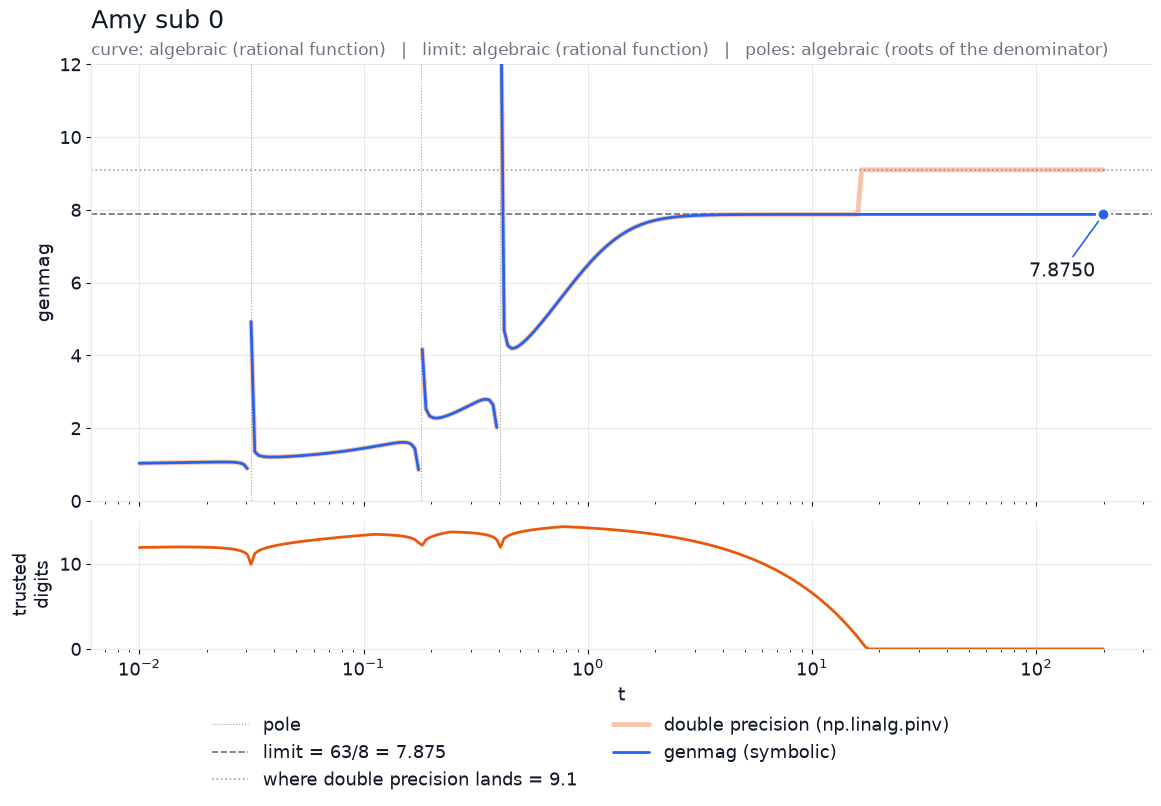

In [3]:
SUB_NO = 0
dissim = datasets.dissimilarity("amy", sub_no=SUB_NO)

start = time.time()
result = magnitude_profile(dissim)
axes, trust_axes = plot_magnitude_profile(
    result, title=f"Amy sub {SUB_NO}", ylim=(0, 12))

print(f"elapsed      : {time.time() - start:.0f} s")
print(f"limit        : {result.limit}   ({result.limit_decimal})")
print(f"  route      : {result.limit_method}, "
      f"{'proved' if result.limit_is_proved else 'certified digits'}")
print(f"m(A(inf))    : {result.limit_at_infinity}   <- where double precision lands")
print(f"rank at inf  : {result.rank_at_infinity} / {result.size}")
print(f"curve route  : {result.curve_method}")
print(f"poles ({len(result.poles)})    : {[round(pole, 6) for pole in result.poles]} "
      f"({result.poles_method})")
for note in result.notes:
    print(f"  note: {note}")


In [6]:
# All 120 subjects. The symbolic route finishes for most of them, so this takes
# minutes rather than seconds; every finished subject is cached under
# data/interim/magnitude_profiles, so a second run returns immediately and an
# interrupted one resumes.

dissims = datasets.amy_all_subjects()

summary, results = magnitude_profiles(
    dissims,
    name="amy",
    max_workers=max(1, (os.cpu_count() or 2) - 1),
)
summary.to_csv(paths.table("amy_magnitude_profiles.csv"))
print(summary["status"].value_counts())
print(summary["limit_method"].value_counts())
summary.head()


0 cached, 120 to compute
[1/120] subject=5 ok (0.5s)
[2/120] subject=7 ok (0.4s)
[3/120] subject=6 ok (18.7s)
[4/120] subject=4 ok (19.8s)
[5/120] subject=1 ok (21.5s)
[6/120] subject=2 ok (22.1s)
[7/120] subject=0 ok (24.3s)
[8/120] subject=9 ok (6.8s)
[9/120] subject=13 ok (7.2s)
[10/120] subject=12 ok (32.0s)
[11/120] subject=15 ok (24.9s)
[12/120] subject=3 ok (61.0s)
[13/120] subject=8 ok (61.0s)
[14/120] subject=11 ok (44.1s)
[15/120] subject=10 ok (46.9s)
[16/120] subject=21 ok (0.6s)
[17/120] subject=17 ok (20.6s)
[18/120] subject=23 ok (0.6s)
[19/120] subject=16 ok (27.3s)
[20/120] subject=19 ok (21.1s)
[21/120] subject=18 ok (24.7s)
[22/120] subject=14 ok (60.7s)
[23/120] subject=22 ok (25.7s)
[24/120] subject=29 ok (0.6s)
[25/120] subject=25 ok (13.0s)
[26/120] subject=20 ok (28.9s)
[27/120] subject=32 ok (0.6s)
[28/120] subject=26 ok (21.4s)
[29/120] subject=24 ok (32.0s)
[30/120] subject=27 ok (23.9s)
[31/120] subject=31 ok (21.9s)
[32/120] subject=33 ok (24.2s)
[33/120] s

,status,sec,error,size,rank_at_infinity,limit,limit_float,limit_decimal,limit_method,limit_is_proved,curve_method,poles_method,n_poles,n_blind
subject,,,,,,,,,,,,,,
0,ok,24.279078,NaN,23.0,22.0,63/8,7.875,7.875,symbolic,True,symbolic,symbolic,3.0,0.0
1,ok,21.532837,NaN,23.0,22.0,17,17.000,17,symbolic,True,symbolic,symbolic,2.0,0.0
2,ok,22.056429,NaN,23.0,20.0,81/5,16.200,16.2,symbolic,True,symbolic,symbolic,3.0,0.0
3,ok,61.002115,NaN,23.0,13.0,None,NaN,nan,arbitrary_precision,False,arbitrary_precision,sign_change,0.0,260.0
4,ok,19.794706,NaN,23.0,22.0,21,21.000,21,symbolic,True,symbolic,symbolic,6.0,0.0


AttributeError: 'Axes' object has no attribute 'close'

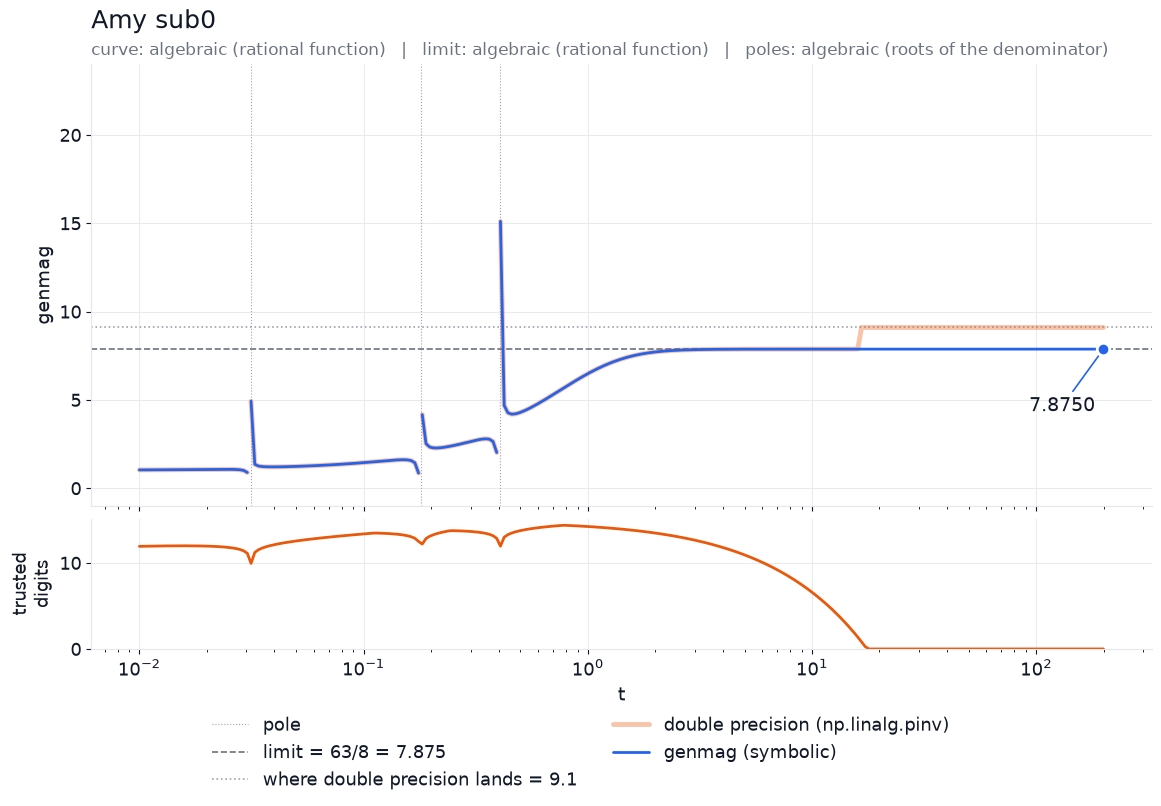

In [8]:
# Draw a few of them. Each call makes its own figure, with the panel showing
# how far double precision can be trusted underneath.

#targets = [0, 1, 2, 3]
targets = list(range(120))
for sub_no in targets:
    if sub_no not in results:
        print(f"sub {sub_no}: {summary.loc[sub_no, 'status']}")
        continue
    main_axes, trust_axes = plot_magnitude_profile(results[sub_no], title=f"Amy sub{sub_no}", ylim=(-1, 24))
    figpath = Path.cwd().parent.parent / f"results/figures/profile_amy_{sub_no}.png"
    main_axes.figure.savefig(figpath, dpi=300)
    main_axes.close()